In [9]:
import pandas as pd
import numpy as np

In [36]:
df = pd.read_csv("flower.csv")
df.columns

Index(['decision_variable', 'vanillaNAS_dense_best_acc',
       'JimmyNAS_I_fullyCNN_best_acc', 'vanillaNAS_dense_tflite_acc',
       'JimmyNAS_I_fullyCNN_tflite_acc', 'vanillaNAS_dense_macs',
       'JimmyNAS_I_fullyCNN_macs', 'vanillaNAS_dense_flash',
       'JimmyNAS_I_fullyCNN_flash', 'vanillaNAS_dense_peak_ram',
       'JimmyNAS_I_fullyCNN_peak_ram', 'vanillaNAS_dense_param_count',
       'JimmyNAS_I_fullyCNN_param_count'],
      dtype='str')

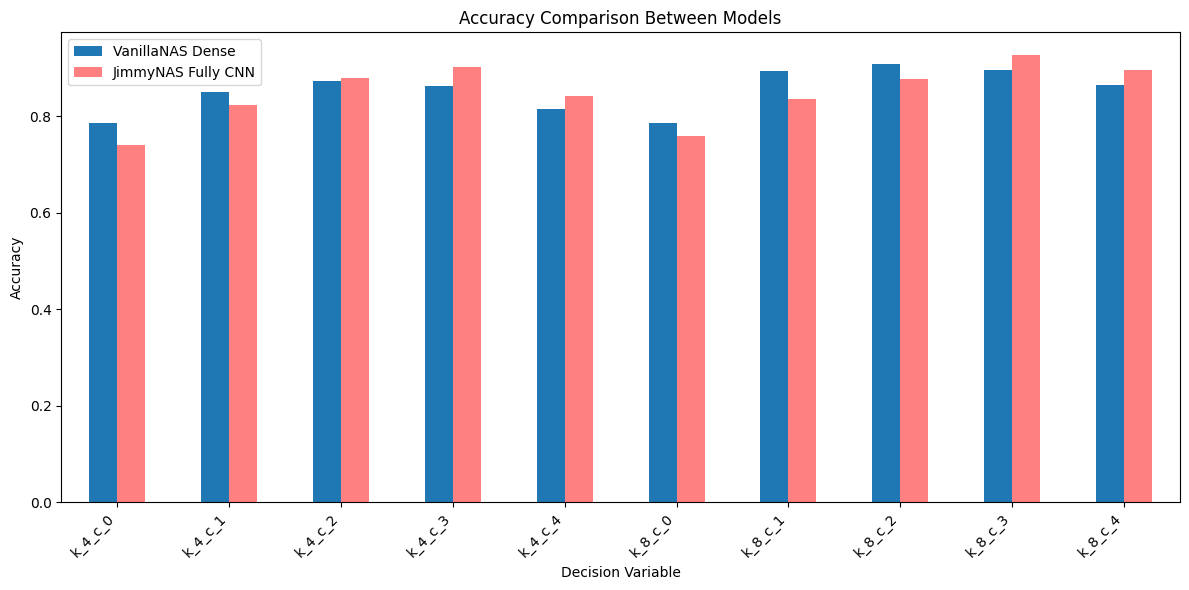

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("flower.csv")

df.plot(
    x="decision_variable",
    y=["vanillaNAS_dense_best_acc", "JimmyNAS_I_fullyCNN_best_acc"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("Accuracy")
plt.xlabel("Decision Variable")
plt.title("Accuracy Comparison Between Models")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()

# win 5   lose 5


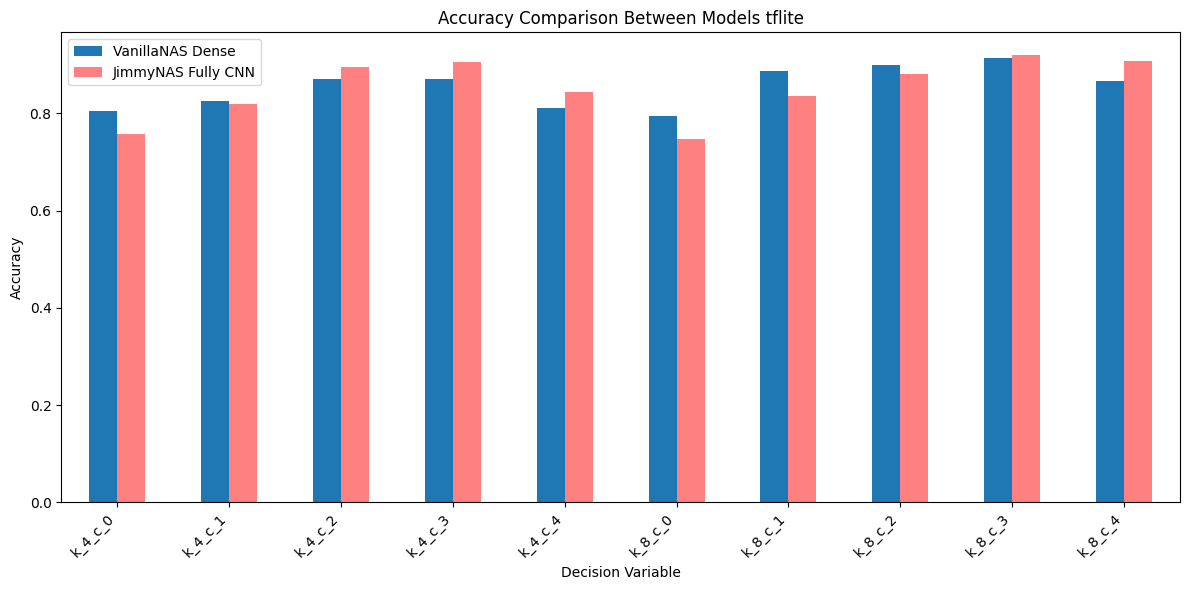

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("flower.csv")

df.plot(
    x="decision_variable",
    y=["vanillaNAS_dense_tflite_acc", "JimmyNAS_I_fullyCNN_tflite_acc"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("Accuracy")
plt.xlabel("Decision Variable")
plt.title("Accuracy Comparison Between Models tflite")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()


# win 5   lose 5

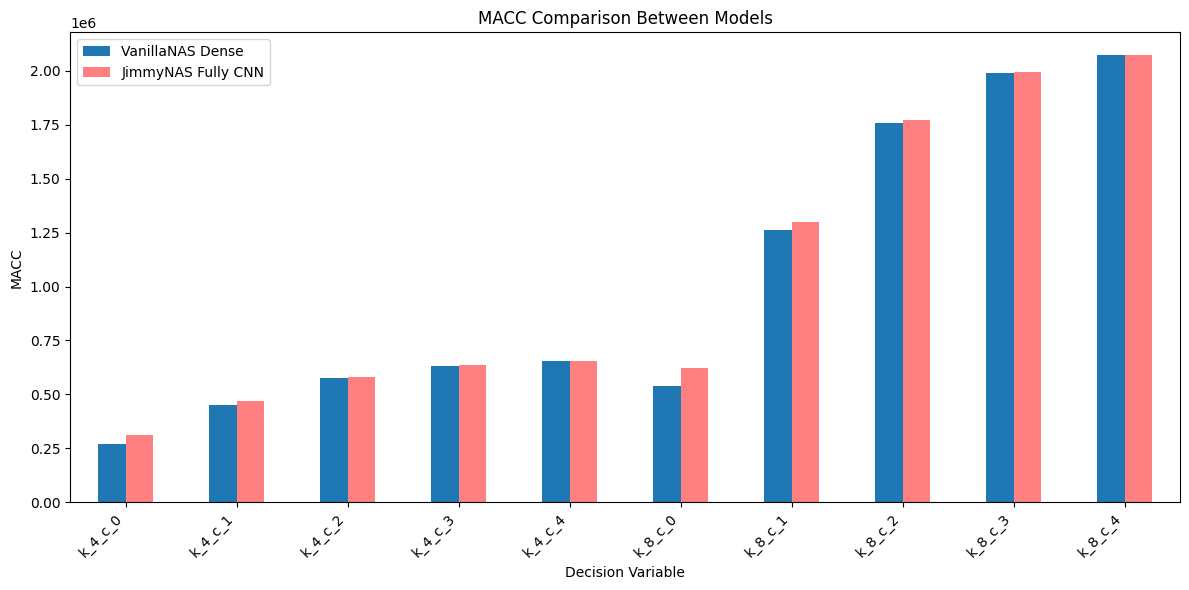

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("flower.csv")

df.plot(
    x="decision_variable",
    y=["vanillaNAS_dense_macs", "JimmyNAS_I_fullyCNN_macs"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("MACC")
plt.xlabel("Decision Variable")
plt.title("MACC Comparison Between Models")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()

# MACC jimmy ใช้เยอะกว่า baseline จากโดยรวม


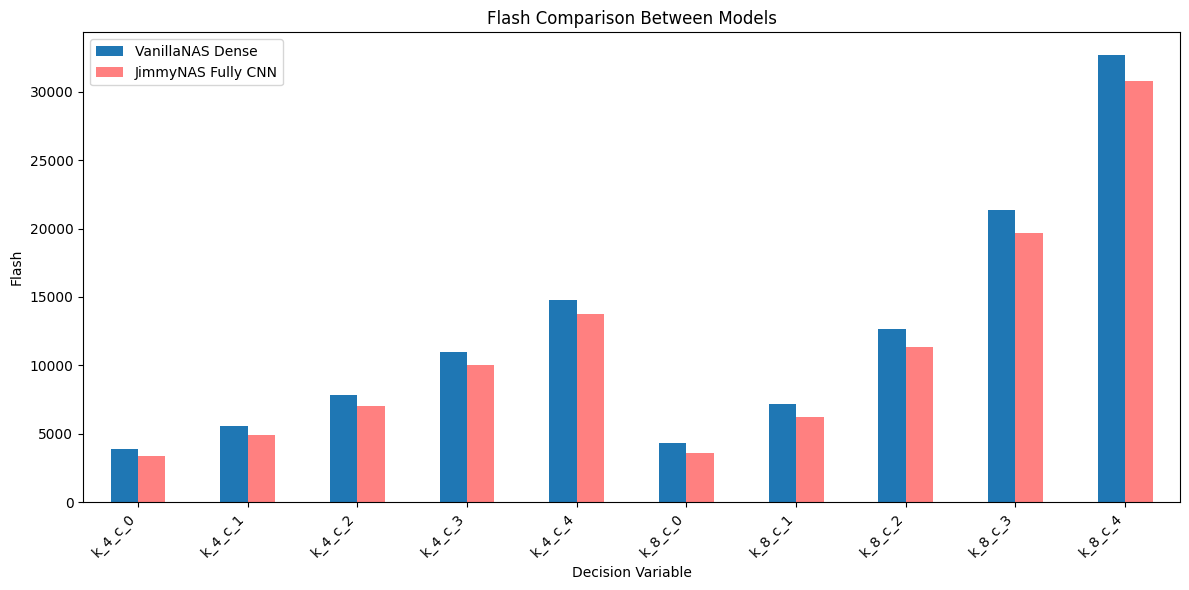

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("flower.csv")

df.plot(
    x="decision_variable",
    y=["vanillaNAS_dense_flash", "JimmyNAS_I_fullyCNN_flash"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("Flash")
plt.xlabel("Decision Variable")
plt.title("Flash Comparison Between Models")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()

# Flash ของ baseline ใช้เยอะกว่า Jimmy อย่างเห็นได้ชัด

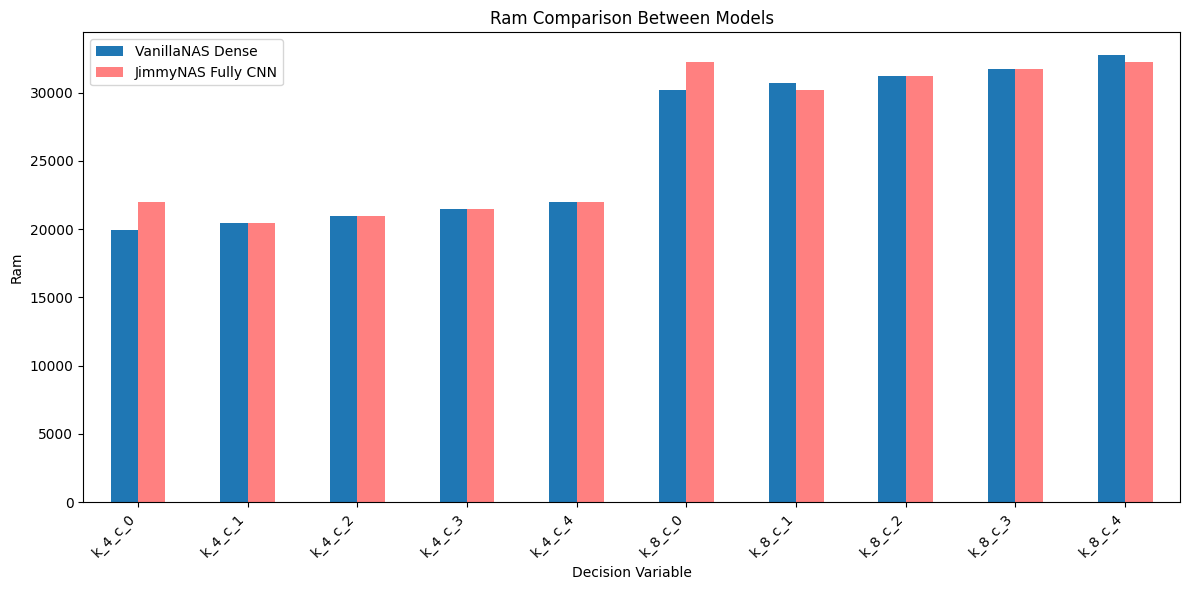

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("flower.csv")

df.plot(
    x="decision_variable",
    y=["vanillaNAS_dense_peak_ram", "JimmyNAS_I_fullyCNN_peak_ram"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("Ram")
plt.xlabel("Decision Variable")
plt.title("Ram Comparison Between Models")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()

# Ram ในบางช่วง Jimmy จะใช้เยอะกว่าเมื่อมีเลเยอร์ต่ำ

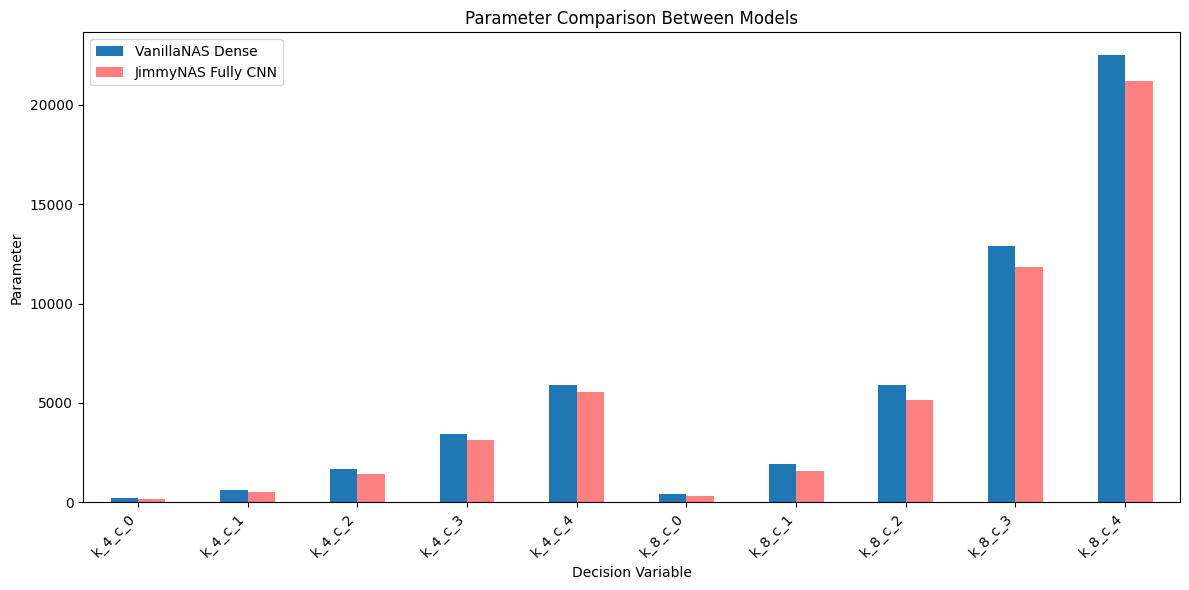

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("flower.csv")

df.plot(
    x="decision_variable",
    y=["vanillaNAS_dense_param_count", "JimmyNAS_I_fullyCNN_param_count"],
    kind="bar",
    color=["#1f77b4", "#ff8080"],
    figsize=(12, 6)
)

plt.ylabel("Parameter")
plt.xlabel("Decision Variable")
plt.title("Parameter Comparison Between Models")
plt.xticks(rotation=45, ha="right")
plt.legend(["VanillaNAS Dense", "JimmyNAS Fully CNN"])
plt.tight_layout()
plt.show()

# parameter ของ baseline จะมีจำนวน parameter เยอะกว่า Jimmy

In [ ]:
# win 5   lose 5  full
# win 5   lose 5  tflite
# MACC jimmy ใช้เยอะกว่า baseline จากโดยรวม
# Flash ของ baseline ใช้เยอะกว่า Jimmy อย่างเห็นได้ชัด
# Ram ในบางช่วง Jimmy จะใช้เยอะกว่าเมื่อมีเลเยอร์ต่ำ
# parameter ของ baseline จะมีจำนวน parameter เยอะกว่า Jimmy

In [38]:
df_cmp = df.copy()
metrics = [
    "best_acc",
    "tflite_acc",
    "macs",
    "flash",
    "peak_ram",
    "param_count"
]
higher_better = ["best_acc", "tflite_acc"]

for m in metrics:
    v_col = f"vanillaNAS_dense_{m}"
    j_col = f"JimmyNAS_I_fullyCNN_{m}"

    if m in higher_better:
        df_cmp[f"{m}_result"] = (
            (df_cmp[j_col] > df_cmp[v_col]).map({True: "Win", False: "Lose"})
        )
    else:
        df_cmp[f"{m}_result"] = (
            (df_cmp[j_col] < df_cmp[v_col]).map({True: "Win", False: "Lose"})
        )

    # Handle Draws
    df_cmp.loc[df_cmp[j_col] == df_cmp[v_col], f"{m}_result"] = "Draw"

result_cols = [f"{m}_result" for m in metrics]

df_cmp["overall_result"] = (
    df_cmp[result_cols]
    .apply(lambda r: 
           "Win" if (r == "Win").sum() > (r == "Lose").sum()
           else "Lose" if (r == "Lose").sum() > (r == "Win").sum()
           else "Draw",
           axis=1)
)

cols_to_show = ["decision_variable"] + result_cols + ["overall_result"]
df_cmp[cols_to_show]

# Win → JimmyNAS better

# Lose → VanillaNAS better

# Draw → Same value

,decision_variable,best_acc_result,tflite_acc_result,macs_result,flash_result,peak_ram_result,param_count_result,overall_result
0,k_4_c_0,Lose,Lose,Lose,Win,Lose,Win,Lose
1,k_4_c_1,Lose,Lose,Lose,Win,Draw,Win,Lose
2,k_4_c_2,Win,Win,Lose,Win,Draw,Win,Win
3,k_4_c_3,Win,Win,Lose,Win,Draw,Win,Win
4,k_4_c_4,Win,Win,Lose,Win,Draw,Win,Win
5,k_8_c_0,Lose,Lose,Lose,Win,Lose,Win,Lose
6,k_8_c_1,Lose,Lose,Lose,Win,Win,Win,Draw
7,k_8_c_2,Lose,Lose,Lose,Win,Draw,Win,Lose
8,k_8_c_3,Win,Win,Lose,Win,Draw,Win,Win
9,k_8_c_4,Win,Win,Lose,Win,Win,Win,Win
